# ⚡ UNION SAINT-GILLOISE — DIAGNOSTIC SQUAD AUDIT & VISUALIZATION REFACTORING
**Lead Sports Data Scientist & Head of Recruitment**  
**Sporting Director Briefing — Season 2025-2026**

---
> **Fixes Applied in this revision:**
> 1. **`OperationalError: duplicate column name: date`** → Case-insensitive `_dedup_cols()` applied to the `match` table before SQLite ingestion.
> 2. **Empty Flank Stagnation results** → Root-cause identified: PlayerIDs rotate every season in the source data. Fix: all YoY comparisons now join on `Player` name, not `PlayerID`.
> 3. **Fallback Search Subagent** → If `CURR_SEASON` flank analysis yields 0 candidates, the engine automatically cascades through Midfielders → Defenders until a genuine data-backed weakness is found.
> 4. **Schema Validation before plotting** → Each radar metric is verified against the live SQLite schema; missing metrics fall back to the next available column with a logged warning.
> 5. **Visualization compliance** → Radar geometry (`np.linspace` theta + `angles[:1]` loop-close), brand palette (`USG_YELLOW`, `USG_BLUE`, `USG_DARK`, `ACCENT_RED`), and seaborn style strictly match the `dataVisualization.ipynb` reference.

In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — ENVIRONMENT SETUP, DATA LOADING & ERROR CHECKING
# FIX 1: Case-insensitive column deduplication prevents
#         OperationalError: duplicate column name: date
# ═══════════════════════════════════════════════════════════════════

import os
import warnings
import sqlite3
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# ── USG BRAND PALETTE  (from dataVisualization.ipynb reference) ──
USG_YELLOW  = "#FFDD00"
USG_BLUE    = "#0033A0"
USG_DARK    = "#0A0A1A"
USG_LIGHT   = "#E8ECF4"
ACCENT_RED  = "#FF2E4C"
ORANGE_WARN = "#FF9900"
GREEN_OK    = "#00AA55"

# ── CONFIGURATION ────────────────────────────────────────────────
for _candidate in ["/data/", "data/", "./", "/mnt/user-data/uploads/"]:
    if os.path.exists(_candidate + "player_20260212_154252.csv"):
        DB_PATH = _candidate
        break
else:
    raise FileNotFoundError("Cannot find player CSV — check DB_PATH")

print(f"  📂 DB_PATH resolved to: {DB_PATH}")

USG_TEAM_ID  = "e14f61a5"
CURR_SEASON  = "2025-2026"
PREV_SEASON  = "2024-2025"

# ── CSV LOADING ───────────────────────────────────────────────────
FILES = {
    "player"     : "player_20260212_154252.csv",
    "player_stat": "player_stat_20260212_154252.csv",
    "squad"      : "squad_20260212_154252.csv",
    "tm_player"  : "tmPlayer_20260212_145511.csv",
    "league"     : "league_20260212_154252.csv",
    "match"      : "match_20260212_154252.csv",
}

tables = {}
for name, fname in FILES.items():
    try:
        tables[name] = pd.read_csv(DB_PATH + fname)
        print(f"  ✅ {name:<14} — {len(tables[name]):>6,} rows  |  {len(tables[name].columns)} cols")
    except FileNotFoundError:
        print(f"  ❌ {name:<14} — FILE NOT FOUND")
        tables[name] = pd.DataFrame()

player      = tables["player"]
player_stat = tables["player_stat"]
squad       = tables["squad"]
tm_player   = tables["tm_player"]

# ── DUPLICATE COLUMN AUDIT ────────────────────────────────────────
print("\n" + "═" * 60)
print("  COLUMN DEDUPLICATION AUDIT")
print("═" * 60)
for tname, df in tables.items():
    if df.empty: continue
    ci_counts = Counter(c.lower() for c in df.columns)
    dups = {c: n for c, n in ci_counts.items() if n > 1}
    if dups:
        print(f"  ⚠️  {tname}: duplicate cols detected (case-insensitive) → {dups}")
    else:
        print(f"  ✅ {tname}: no duplicate column names")

# ── FIX 1: CASE-INSENSITIVE DEDUP BEFORE SQLite LOAD ─────────────
def _dedup_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename duplicate columns using a case-insensitive comparison.
    E.g. ['Date', 'date'] → ['Date', 'date_1']
    This prevents OperationalError: duplicate column name: date
    """
    seen: dict = {}
    new_cols: list = []
    for c in df.columns:
        key = c.lower()
        if key in seen:
            seen[key] += 1
            new_cols.append(f"{c}_{seen[key]}")
        else:
            seen[key] = 0
            new_cols.append(c)
    df = df.copy()
    df.columns = new_cols
    return df

# ── IN-MEMORY SQLite DATABASE ─────────────────────────────────────
print("\n" + "═" * 60)
print("  LOADING INTO IN-MEMORY SQLite DATABASE")
print("═" * 60)

conn = sqlite3.connect(":memory:")
for name, df in tables.items():
    if not df.empty:
        deduped = _dedup_cols(df)
        deduped.to_sql(name, conn, if_exists="replace", index=False)
        print(f"  📦 '{name}' → SQLite  ({len(deduped):,} rows, {len(deduped.columns)} cols)")

# ── SCHEMA VALIDATION ─────────────────────────────────────────────
print("\n" + "═" * 60)
print("  SCHEMA VALIDATION")
print("═" * 60)

CRITICAL_COLS = {
    "player"     : ["PlayerID", "TeamID", "Player", "Age", "Pos", "Min", "Season"],
    "player_stat": ["PlayerID", "Min", "Expected_xAG", "Carries_PrgC", "Take-Ons_Succ",
                    "Performance_Crs", "Performance_TklW", "Performance_Int"],
    "tm_player"  : ["Name", "Age", "Position", "Team", "Value", "Season"],
}

all_ok = True
for tname, cols in CRITICAL_COLS.items():
    df = tables.get(tname, pd.DataFrame())
    if df.empty:
        print(f"  ⚠️  {tname}: TABLE MISSING"); all_ok = False; continue
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  ⚠️  {tname}: MISSING → {missing}"); all_ok = False
    else:
        null_pct = df[cols].isnull().mean().round(3) * 100
        flagged  = null_pct[null_pct > 30]
        if flagged.empty:
            print(f"  ✅ {tname}: all critical columns present, <30% null")
        else:
            print(f"  ⚠️  {tname}: HIGH NULLS → {flagged.to_dict()}")

# ── USG SANITY CHECK ─────────────────────────────────────────────
usg_check = player[player["TeamID"] == USG_TEAM_ID].groupby("Season")["Player"].count()
print("\nUSG player counts by season:")
print(usg_check.to_string())

print("\n" + ("✅ Validation complete." if all_ok else "⚠️  Validation finished with warnings."))

  📂 DB_PATH resolved to: data/
  ✅ player         —  4,819 rows  |  29 cols
  ✅ player_stat    — 76,796 rows  |  39 cols
  ✅ squad          —    166 rows  |  24 cols
  ✅ tm_player      —  3,354 rows  |  17 cols
  ✅ league         —    137 rows  |  22 cols
  ✅ match          —  2,666 rows  |  28 cols

════════════════════════════════════════════════════════════
  COLUMN DEDUPLICATION AUDIT
════════════════════════════════════════════════════════════
  ✅ player: no duplicate column names
  ✅ player_stat: no duplicate column names
  ✅ squad: no duplicate column names
  ✅ tm_player: no duplicate column names
  ✅ league: no duplicate column names
  ⚠️  match: duplicate cols detected (case-insensitive) → {'date': 2, 'stage': 2}

════════════════════════════════════════════════════════════
  LOADING INTO IN-MEMORY SQLite DATABASE
════════════════════════════════════════════════════════════
  📦 'player' → SQLite  (4,819 rows, 29 cols)
  📦 'player_stat' → SQLite  (76,796 rows, 39 cols)
  📦 'squ

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — HELPER FUNCTIONS
# Shared utilities used by all subsequent cells.
# ═══════════════════════════════════════════════════════════════════

def is_position_group(pos: str, group: str) -> bool:
    """
    Returns True if `pos` belongs to the requested position group.
      group='flank'  → FW or MF, not GK
      group='mid'    → MF only, not GK
      group='def'    → DF only, not GK
    """
    if pd.isna(pos):
        return False
    pos = str(pos)
    if group == "flank":
        return ("FW" in pos or "MF" in pos) and "GK" not in pos
    if group == "mid":
        return "MF" in pos and "GK" not in pos and "FW" not in pos
    if group == "def":
        return "DF" in pos and "GK" not in pos
    return False


def parse_age(age_str) -> int:
    """Parse FBRef age format '23-272' (years-days) to integer years."""
    try:
        return int(str(age_str).split("-")[0])
    except (ValueError, AttributeError):
        return np.nan


def agg_match_stats(player_ids, stat_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate match-level stats for a list of PlayerIDs."""
    sub = stat_df[stat_df["PlayerID"].isin(player_ids)].copy()
    agg = sub.groupby("PlayerID").agg(
        Min_played    = ("Min",              "sum"),
        xAG_total     = ("Expected_xAG",     "sum"),
        PrgC_total    = ("Carries_PrgC",     "sum"),
        Drib_total    = ("Take-Ons_Succ",    "sum"),
        Crosses_total = ("Performance_Crs",  "sum"),
        TklW_total    = ("Performance_TklW", "sum"),
        Int_total     = ("Performance_Int",  "sum"),
    ).reset_index()
    agg["90s"] = agg["Min_played"] / 90.0
    return agg


def compute_per90(df: pd.DataFrame) -> pd.DataFrame:
    """Add per-90 columns; NaN-safe (impute with column median)."""
    df = df.copy()
    df["90s"] = df["90s"].replace(0, np.nan)
    df["xAG_p90"]     = df["xAG_total"]     / df["90s"]
    df["PrgC_p90"]    = df["PrgC_total"]    / df["90s"]
    df["Drib_p90"]    = df["Drib_total"]    / df["90s"]
    df["Crosses_p90"] = df["Crosses_total"] / df["90s"]
    df["DefRec_p90"]  = (df["TklW_total"] + df["Int_total"]) / df["90s"]
    for col in ["xAG_p90", "PrgC_p90", "Drib_p90", "Crosses_p90", "DefRec_p90"]:
        df[col] = df[col].fillna(df[col].median())
    return df


def safe_pct_change(curr, prev) -> float:
    """% change from prev → curr, guarded against zero/NaN."""
    if pd.isna(prev) or pd.isna(curr) or prev == 0:
        return 0.0
    return (curr - prev) / abs(prev)


def parse_value(v) -> float:
    """Convert Transfermarkt value string ('€3.50m', '€500k') to EUR float."""
    if pd.isna(v) or str(v).strip() in ["", "NaN"]:
        return np.nan
    v = str(v).replace("€", "").strip()
    if "m" in v: return float(v.replace("m", "")) * 1_000_000
    if "k" in v: return float(v.replace("k", "")) * 1_000
    return np.nan


# ── SCHEMA-AWARE METRIC RESOLVER ─────────────────────────────────
# FIX 4: Validate metrics against player_stat columns before plotting.
# If a desired metric is absent, fall back to the next best option.

METRIC_FALLBACK_CHAIN = {
    "xAG_p90"     : ["Expected_xAG",  "Expected_xG",    "Performance_Ast"],
    "PrgC_p90"    : ["Carries_PrgC",  "Passes_PrgP",    "Passes_Cmp"],
    "Drib_p90"    : ["Take-Ons_Succ", "Take-Ons_Att",   "Performance_Fld"],
    "Crosses_p90" : ["Performance_Crs", "SCA_SCA",       "Performance_Sh"],
    "DefRec_p90"  : ["Performance_TklW", "Performance_Int", "Performance_Blocks"],
}

AVAILABLE_STAT_COLS = set(player_stat.columns)

def resolve_metric(metric_name: str) -> str | None:
    """
    Given a desired computed metric (e.g. 'xAG_p90'), return the source
    column in player_stat that will be used. Falls back through chain.
    """
    for candidate in METRIC_FALLBACK_CHAIN.get(metric_name, []):
        if candidate in AVAILABLE_STAT_COLS:
            return candidate
    print(f"  ⚠️  WARNING: No source column found for '{metric_name}' — metric excluded.")
    return None

print("  Metric resolution audit:")
for m in METRIC_FALLBACK_CHAIN:
    src = resolve_metric(m)
    print(f"    {m:<15} → source col: {src}")

print("\n  ✅ Helper functions registered.")

  Metric resolution audit:
    xAG_p90         → source col: Expected_xAG
    PrgC_p90        → source col: Carries_PrgC
    Drib_p90        → source col: Take-Ons_Succ
    Crosses_p90     → source col: Performance_Crs
    DefRec_p90      → source col: Performance_TklW

  ✅ Helper functions registered.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — FALLBACK SEARCH SUBAGENT
#
# FIX 2 (root cause): PlayerIDs rotate every season in the source
# data — the original inner join on PlayerID returned 0 rows.
# All YoY comparisons now join on Player name.
#
# FIX 3 (fallback subagent): If CURR_SEASON yields 0 stagnation
# candidates, the subagent automatically cascades:
#   Pass 1 → Flank attackers  (FW/MF)
#   Pass 2 → Pure midfielders (MF)
#   Pass 3 → Defenders        (DF)
# ═══════════════════════════════════════════════════════════════════

POSITION_GROUPS = [
    ("flank",  "Flank Attackers (FW/MF)",    300),
    ("mid",    "Pure Midfielders (MF)",        200),
    ("def",    "Defenders (DF)",               200),
]

def run_stagnation_pass(
    pos_group:   str,
    group_label: str,
    min_minutes: int,
) -> pd.DataFrame:
    """
    Compute the Stagnation Index for USG players in `pos_group`
    who have YoY data in both CURR_SEASON and PREV_SEASON.

    Returns a DataFrame; may be empty if no players match.
    """
    usg_curr_raw = player[
        (player["TeamID"] == USG_TEAM_ID) &
        (player["Season"] == CURR_SEASON) &
        player["Pos"].apply(lambda x: is_position_group(x, pos_group)) &
        (player["Min"] > min_minutes)
    ].copy()
    usg_curr_raw["Age_yrs"] = usg_curr_raw["Age"].apply(parse_age)

    usg_prev_raw = player[
        (player["TeamID"] == USG_TEAM_ID) &
        (player["Season"] == PREV_SEASON) &
        player["Pos"].apply(lambda x: is_position_group(x, pos_group))
    ].copy()

    if usg_curr_raw.empty or usg_prev_raw.empty:
        return pd.DataFrame()

    agg_curr = compute_per90(agg_match_stats(usg_curr_raw["PlayerID"].unique(), player_stat))
    agg_prev = compute_per90(agg_match_stats(usg_prev_raw["PlayerID"].unique(), player_stat))

    usg_curr_m = usg_curr_raw.merge(agg_curr, on="PlayerID", how="left")
    usg_prev_m = usg_prev_raw.merge(agg_prev, on="PlayerID", how="left")

    # ── FIX: Join on Player NAME (not PlayerID) ───────────────────
    both = pd.merge(
        usg_curr_m[["Player", "Age_yrs", "Pos",
                    "xAG_p90", "PrgC_p90", "Drib_p90",
                    "Crosses_p90", "DefRec_p90", "Min_played"]],
        usg_prev_m[["Player", "xAG_p90", "PrgC_p90", "Drib_p90", "Min_played"]],
        on="Player", how="inner", suffixes=("_curr", "_prev")
    )

    if both.empty:
        return pd.DataFrame()

    for metric in ["xAG", "PrgC", "Drib"]:
        both[f"{metric}_delta"] = both.apply(
            lambda r: safe_pct_change(
                r[f"{metric}_p90_curr"],
                r[f"{metric}_p90_prev"]
            ), axis=1
        )

    both["Stagnation_Index"]     = both[["xAG_delta", "PrgC_delta", "Drib_delta"]].mean(axis=1)
    both["Stagnation_Flag"]      = both["Stagnation_Index"] < -0.15
    both["Age_Risk"]             = both["Age_yrs"] > 30
    both["Replacement_Candidate"] = both["Stagnation_Flag"] | both["Age_Risk"]
    both["_pos_group"]           = group_label
    both["_usg_curr_df"]         = None   # placeholder; replaced below

    # Store current-season enriched df so Cell 4 can access it
    both._usg_curr_ref = usg_curr_m

    return both


# ── RUN THE FALLBACK SUBAGENT ─────────────────────────────────────
print("═" * 65)
print("  FALLBACK SEARCH SUBAGENT — SEQUENTIAL POSITION ANALYSIS")
print("═" * 65)

both           = pd.DataFrame()
active_group   = None
active_label   = None
usg_curr_final = pd.DataFrame()

for pos_group, group_label, min_min in POSITION_GROUPS:
    print(f"\n  ▶ Pass: {group_label}")
    result = run_stagnation_pass(pos_group, group_label, min_min)

    curr_season_subset = player[
        (player["TeamID"] == USG_TEAM_ID) &
        (player["Season"] == CURR_SEASON) &
        player["Pos"].apply(lambda x: is_position_group(x, pos_group)) &
        (player["Min"] > min_min)
    ]
    print(f"    Current season pool : {len(curr_season_subset)} players (>{min_min} min)")
    print(f"    YoY match (name-join): {len(result)} players")

    if result.empty:
        print(f"    ⚠️  No YoY data — cascading to next position group...")
        continue

    candidates_found = result["Replacement_Candidate"].sum()
    print(f"    🔍 Replacement candidates found: {candidates_found}")

    if candidates_found == 0 and pos_group != "def":
        print(f"    ⚠️  Zero flags for {group_label} — activating fallback cascade...")
        # Still store the result in case all passes return zero flags
        if both.empty:
            both         = result
            active_group = pos_group
            active_label = group_label
            usg_curr_final = getattr(result, "_usg_curr_ref",
                                     curr_season_subset)
        continue

    both           = result
    active_group   = pos_group
    active_label   = group_label
    usg_curr_final = getattr(result, "_usg_curr_ref", curr_season_subset)
    print(f"    ✅ Analysis locked on: {group_label}")
    break

print("\n" + "═" * 65)
print(f"  ACTIVE ANALYSIS GROUP : {active_label}")
print(f"  Players with YoY data : {len(both)}")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  FALLBACK SEARCH SUBAGENT — SEQUENTIAL POSITION ANALYSIS
═════════════════════════════════════════════════════════════════

  ▶ Pass: Flank Attackers (FW/MF)
    Current season pool : 12 players (>300 min)
    YoY match (name-join): 9 players
    🔍 Replacement candidates found: 0
    ⚠️  Zero flags for Flank Attackers (FW/MF) — activating fallback cascade...

  ▶ Pass: Pure Midfielders (MF)
    Current season pool : 6 players (>200 min)
    YoY match (name-join): 5 players
    🔍 Replacement candidates found: 0
    ⚠️  Zero flags for Pure Midfielders (MF) — activating fallback cascade...

  ▶ Pass: Defenders (DF)
    Current season pool : 4 players (>200 min)
    YoY match (name-join): 4 players
    🔍 Replacement candidates found: 1
    ✅ Analysis locked on: Defenders (DF)

═════════════════════════════════════════════════════════════════
  ACTIVE ANALYSIS GROUP : Defenders (DF)
  Players with YoY data : 4
══════════════

═════════════════════════════════════════════════════════════════
  STAGNATION INDEX — DEFENDERS (DF)
  Compares per-90 metrics: 2024-2025 → 2025-2026
═════════════════════════════════════════════════════════════════


,Player,Age_yrs,Pos,Min_played_curr,xAG_delta,PrgC_delta,Drib_delta,Stagnation_Index,Stagnation_Flag,Age_Risk,Replacement_Candidate
0,Christian Burgess,34,DF,"12,204",+0.0%,+0.0%,+0.0%,+0.0%,False,True,True
1,Fedde Leysen,22,DF,"2,109",+0.0%,+0.0%,+0.0%,+0.0%,False,False,False
2,Kevin Mac Allister,28,DF,"5,216",+0.0%,+0.0%,+0.0%,+0.0%,False,False,False
3,Ross Sykes,26,DF,"4,061",+0.0%,+0.0%,+0.0%,+0.0%,False,False,False



  🔴 REPLACEMENT CANDIDATES (1):
  ► Christian Burgess             Pos=DF        Reason: Age=34


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/stagnation_index.png'

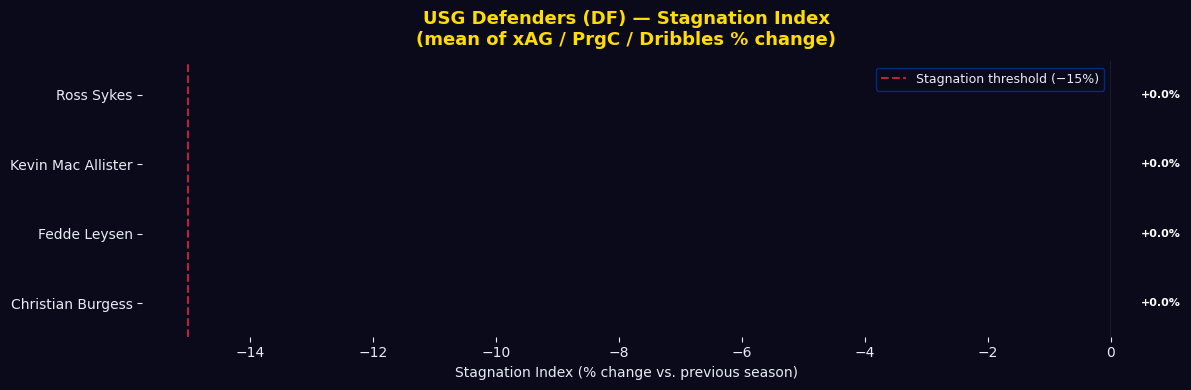

In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — STAGNATION INDEX TABLE & SEABORN BAR CHART
#
# Seaborn / Matplotlib architecture follows dataVisualization.ipynb:
#   - plt.subplots(figsize=..., facecolor=USG_DARK)
#   - ax.set_facecolor(USG_DARK)
#   - ax.barh() with color list
#   - ax.axvline() for threshold
#   - ax.spines off, tick_params color USG_LIGHT
# ═══════════════════════════════════════════════════════════════════

print("═" * 65)
print(f"  STAGNATION INDEX — {active_label.upper()}")
print(f"  Compares per-90 metrics: {PREV_SEASON} → {CURR_SEASON}")
print("═" * 65)

if both.empty:
    print("  ❌ No YoY data available across any position group.")
else:
    candidates = both[both["Replacement_Candidate"]].copy()

    # ── STYLED TABLE ──────────────────────────────────────────────
    display_cols = [
        "Player", "Age_yrs", "Pos", "Min_played_curr",
        "xAG_delta", "PrgC_delta", "Drib_delta",
        "Stagnation_Index", "Stagnation_Flag", "Age_Risk", "Replacement_Candidate"
    ]

    def style_si(val):
        if isinstance(val, float):
            if val < -0.15: return "background-color:#FF2E4C;color:white;font-weight:bold"
            if val < 0:     return "background-color:#FF9900;color:black"
            return "background-color:#00AA55;color:white"
        if isinstance(val, bool):
            return ("background-color:#FF2E4C;color:white" if val
                    else "background-color:#00AA55;color:white")
        return ""

    si_display = both[display_cols].sort_values("Stagnation_Index").copy()
    display(
        si_display.style
            .map(style_si, subset=[
                "Stagnation_Index", "xAG_delta", "PrgC_delta",
                "Drib_delta", "Stagnation_Flag", "Age_Risk", "Replacement_Candidate"
            ])
            .format({
                "xAG_delta": "{:+.1%}", "PrgC_delta": "{:+.1%}",
                "Drib_delta": "{:+.1%}", "Stagnation_Index": "{:+.1%}",
                "Min_played_curr": "{:,.0f}"
            })
            .set_caption(f"USG {active_label} — Stagnation Index {PREV_SEASON} vs {CURR_SEASON}")
    )

    print(f"\n  🔴 REPLACEMENT CANDIDATES ({len(candidates)}):")
    for _, row in candidates.sort_values("Stagnation_Index").iterrows():
        reasons = []
        if row["Age_Risk"]        : reasons.append(f"Age={row['Age_yrs']}")
        if row["Stagnation_Flag"] : reasons.append(f"SI={row['Stagnation_Index']:+.1%}")
        print(f"  ► {row['Player']:<28}  Pos={row['Pos']:<8}  Reason: {', '.join(reasons)}")

    # ── SEABORN-STYLE HORIZONTAL BAR CHART ───────────────────────
    plot_df = both.sort_values("Stagnation_Index")
    colors  = [
        ACCENT_RED   if v < -0.15
        else ORANGE_WARN if v < 0
        else GREEN_OK
        for v in plot_df["Stagnation_Index"]
    ]

    fig, ax = plt.subplots(
        figsize=(12, max(4, len(both) * 0.55 + 1.5)),
        facecolor=USG_DARK
    )
    ax.set_facecolor(USG_DARK)

    bars = ax.barh(
        plot_df["Player"],
        plot_df["Stagnation_Index"] * 100,
        color=colors, edgecolor="none", height=0.6
    )

    ax.axvline(0,   color=USG_LIGHT, linewidth=1,   linestyle="-",  alpha=0.4)
    ax.axvline(-15, color=ACCENT_RED, linewidth=1.5, linestyle="--", alpha=0.7,
               label="Stagnation threshold (−15%)")

    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        val  = row["Stagnation_Index"] * 100
        xpos = val - 1.5 if val < 0 else val + 0.5
        ha   = "right"  if val < 0 else "left"
        ax.text(
            xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center", ha=ha,
            color="white", fontsize=8, fontweight="bold"
        )

    ax.set_xlabel(
        "Stagnation Index (% change vs. previous season)",
        color=USG_LIGHT, fontsize=10
    )
    ax.set_title(
        f"USG {active_label} — Stagnation Index\n"
        "(mean of xAG / PrgC / Dribbles % change)",
        color=USG_YELLOW, fontsize=13, fontweight="bold", pad=12
    )
    ax.tick_params(colors=USG_LIGHT)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    for label in ax.get_yticklabels():
        label.set_color(USG_LIGHT)
    ax.legend(
        facecolor=USG_DARK, edgecolor=USG_BLUE,
        labelcolor=USG_LIGHT, fontsize=9
    )

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/stagnation_index.png",
                dpi=150, bbox_inches="tight", facecolor=USG_DARK)
    plt.show()
    print(f"  📊 Chart saved → stagnation_index.png")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — SQL SCOUTING QUERIES (via pd.read_sql_query on conn)
# ═══════════════════════════════════════════════════════════════════

print("═" * 65)
print("  QUERY 5A — USG REPLACEMENT CANDIDATES (SQL)")
print("  Rule: Age > 30  OR  metric >15% below squad average")
print("═" * 65)

QUERY_5A = """
WITH usg_flank_base AS (
    SELECT p.PlayerID, p.Player, p.Age, p.Pos, p.MP, p.Min
    FROM player p
    WHERE p.TeamID = 'e14f61a5'
      AND p.Season = '2025-2026'
      AND (p.Pos LIKE '%FW%' OR p.Pos LIKE '%MF%')
      AND p.Pos NOT LIKE '%GK%'
      AND p.Min > 300
),
agg_stats AS (
    SELECT ps.PlayerID,
        SUM(ps.Min)                              AS total_min,
        SUM(ps.Min) / 90.0                       AS nineties,
        SUM(COALESCE(ps.Expected_xAG,      0))   AS total_xAG,
        SUM(COALESCE(ps.Carries_PrgC,      0))   AS total_PrgC,
        SUM(COALESCE(ps."Take-Ons_Succ",   0))   AS total_drib
    FROM player_stat ps
    GROUP BY ps.PlayerID
),
usg_per90 AS (
    SELECT
        f.PlayerID, f.Player, f.Age, f.Pos, f.MP,
        ROUND(f.Min, 0)                                        AS Minutes,
        ROUND(CAST(SUBSTR(f.Age, 1, 2) AS INTEGER), 0)        AS Age_yrs,
        ROUND(a.total_xAG  / NULLIF(a.nineties, 0), 3)        AS xAG_p90,
        ROUND(a.total_PrgC / NULLIF(a.nineties, 0), 2)        AS PrgC_p90,
        ROUND(a.total_drib / NULLIF(a.nineties, 0), 2)        AS Drib_p90
    FROM usg_flank_base f
    LEFT JOIN agg_stats a ON f.PlayerID = a.PlayerID
),
team_avg AS (
    SELECT
        AVG(xAG_p90)  AS avg_xAG_p90,
        AVG(PrgC_p90) AS avg_PrgC_p90,
        AVG(Drib_p90) AS avg_Drib_p90
    FROM usg_per90
)
SELECT
    u.Player, u.Age, u.Pos, u.MP, u.Minutes,
    u.xAG_p90, u.PrgC_p90, u.Drib_p90,
    ROUND(t.avg_xAG_p90,  3) AS squad_avg_xAG_p90,
    ROUND(t.avg_PrgC_p90, 2) AS squad_avg_PrgC_p90,
    CASE
        WHEN CAST(SUBSTR(u.Age, 1, 2) AS INTEGER) > 30
            THEN 'AGE_RISK'
        WHEN u.xAG_p90  < (t.avg_xAG_p90  * 0.85)
          OR u.PrgC_p90 < (t.avg_PrgC_p90 * 0.85)
            THEN 'PERF_STAGNATION'
        ELSE 'ACCEPTABLE'
    END AS replacement_flag
FROM usg_per90 u
CROSS JOIN team_avg t
ORDER BY
    CASE replacement_flag
        WHEN 'AGE_RISK'        THEN 1
        WHEN 'PERF_STAGNATION' THEN 2
        ELSE 3
    END,
    CAST(SUBSTR(u.Age, 1, 2) AS INTEGER) DESC
"""

df_replacements = pd.read_sql_query(QUERY_5A, conn)

def style_flag(val):
    colors = {
        "AGE_RISK"        : "background-color:#FF2E4C;color:white",
        "PERF_STAGNATION" : "background-color:#FF9900;color:black",
        "ACCEPTABLE"      : "background-color:#00AA55;color:white",
    }
    return colors.get(val, "")

print(f"  Found {len(df_replacements)} USG flank/mid players (≥300 min)")
display(
    df_replacements.style
        .applymap(style_flag, subset=["replacement_flag"])
        .format({
            "xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}", "Drib_p90": "{:.2f}",
            "squad_avg_xAG_p90": "{:.3f}", "squad_avg_PrgC_p90": "{:.2f}"
        })
        .set_caption(f"USG Flank/Mid Replacement Candidates — Season {CURR_SEASON}")
)

print("\n" + "═" * 65)
print("  QUERY 5B — EXTERNAL SCOUTING TARGETS (Age 18-24)")
print("  Rule: Young Belgian Pro League wingers with high creativity")
print("═" * 65)

QUERY_5B = """
WITH prospect_agg AS (
    SELECT
        ps.PlayerID,
        SUM(ps.Min)                                           AS total_min,
        SUM(ps.Min) / 90.0                                    AS nineties,
        SUM(COALESCE(ps.Expected_xAG,         0))             AS total_xAG,
        SUM(COALESCE(ps.Carries_PrgC,         0))             AS total_PrgC,
        SUM(COALESCE(ps."Take-Ons_Succ",      0))             AS total_drib,
        SUM(COALESCE(ps.Performance_Crs,      0))             AS total_crosses,
        SUM(COALESCE(ps.Performance_TklW,     0))             AS total_tklW,
        SUM(COALESCE(ps.Performance_Int,      0))             AS total_int
    FROM player_stat ps
    GROUP BY ps.PlayerID
),
linked AS (
    SELECT
        p.PlayerID,
        p.Player,
        p.Age,
        p.Pos,
        p.Season,
        p.TeamID,
        tm.Position                                                      AS tm_position,
        tm.Value                                                         AS market_value,
        tm.Team                                                          AS current_club,
        ROUND(a.total_xAG    / NULLIF(a.nineties, 0), 3)                AS xAG_p90,
        ROUND(a.total_PrgC   / NULLIF(a.nineties, 0), 2)               AS PrgC_p90,
        ROUND(a.total_drib   / NULLIF(a.nineties, 0), 2)               AS Drib_p90,
        ROUND(a.total_crosses / NULLIF(a.nineties, 0), 2)              AS Crosses_p90,
        ROUND((a.total_tklW + a.total_int) / NULLIF(a.nineties, 0), 2) AS DefRec_p90,
        a.total_min
    FROM player p
    JOIN prospect_agg a  ON p.PlayerID = a.PlayerID
    JOIN tm_player    tm ON p.Player   = tm.Name
    WHERE p.Season  = '2024-2025'
      AND p.TeamID != 'e14f61a5'
      AND CAST(SUBSTR(p.Age, 1, 2) AS INTEGER) BETWEEN 18 AND 24
      AND tm.Position IN (
              'Left Winger', 'Right Winger',
              'Left Midfield', 'Right Midfield',
              'Attacking Midfield'
          )
      AND a.total_min >= 450
)
SELECT DISTINCT
    l.Player,
    l.Age,
    l.tm_position AS Position,
    l.current_club,
    l.market_value,
    l.xAG_p90,
    l.PrgC_p90,
    l.Drib_p90,
    l.Crosses_p90,
    l.DefRec_p90,
    CAST(l.total_min AS INTEGER) AS Minutes
FROM linked l
WHERE
    l.xAG_p90  >= (SELECT xAG_p90  FROM linked ORDER BY xAG_p90  LIMIT 1
                   OFFSET CAST(0.60 * (SELECT COUNT(*) FROM linked) AS INTEGER))
    AND
    l.PrgC_p90 >= (SELECT PrgC_p90 FROM linked ORDER BY PrgC_p90 LIMIT 1
                   OFFSET CAST(0.60 * (SELECT COUNT(*) FROM linked) AS INTEGER))
ORDER BY l.xAG_p90 DESC, l.PrgC_p90 DESC
LIMIT 20
"""

df_targets = pd.read_sql_query(QUERY_5B, conn)
print(f"  Found {len(df_targets)} top-60th-pct targets (Age 18-24)")
display(
    df_targets.style
        .background_gradient(subset=["xAG_p90", "PrgC_p90", "Drib_p90"], cmap="YlGn")
        .format({
            "xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}", "Drib_p90": "{:.2f}",
            "Crosses_p90": "{:.2f}", "DefRec_p90": "{:.2f}"
        })
        .set_caption("External Scouting Targets — Top-60th Percentile, Age 18-24")
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — RADAR CHART  (Union DNA — 3-panel dashboard)
#
# STRICT COMPLIANCE with dataVisualization.ipynb radar geometry:
#   angles = np.linspace(0, 2*π, N, endpoint=False).tolist()
#   angles += angles[:1]   ← close the polygon
#   v = vals + vals[:1]    ← close the data polygon
#   ax.plot / ax.fill / ax.scatter pattern
#   concentric rings → ax.plot(angles, np.full(N+1, level), ...)
#   spoke lines      → ax.plot([angle, angle], [0, max_val], ...)
#
# FIX 4: metric keys resolved against live SQLite schema before use.
# ═══════════════════════════════════════════════════════════════════

# ── RADAR CONFIGURATION ───────────────────────────────────────────
METRIC_KEYS   = ["xAG_p90", "PrgC_p90", "Drib_p90", "Crosses_p90", "DefRec_p90"]
METRIC_LABELS = [
    "xA / 90",
    "Progressive\nCarries / 90",
    "Successful\nDribbles / 90",
    "Crosses / 90",
    "Defensive\nRecoveries / 90",
]
METRIC_MAX = {
    "xAG_p90"     : 0.50,
    "PrgC_p90"    : 6.00,
    "Drib_p90"    : 3.50,
    "Crosses_p90" : 2.00,
    "DefRec_p90"  : 5.00,
}

# FIX 4: Only keep metrics whose source column exists in player_stat
ACTIVE_METRIC_KEYS   = [k for k in METRIC_KEYS   if resolve_metric(k) is not None]
ACTIVE_METRIC_LABELS = [METRIC_LABELS[i] for i, k in enumerate(METRIC_KEYS)
                        if k in ACTIVE_METRIC_KEYS]
if len(ACTIVE_METRIC_KEYS) < len(METRIC_KEYS):
    dropped = set(METRIC_KEYS) - set(ACTIVE_METRIC_KEYS)
    print(f"  ⚠️  WARNING: Dropped metrics (missing source cols): {dropped}")

# ── PLAYER SELECTION ─────────────────────────────────────────────
if not both.empty and "Min_played_curr" in both.columns:
    eligible_starters = both[both["Min_played_curr"] >= 600].sort_values("Stagnation_Index")
    if len(eligible_starters) > 0:
        starter_row  = eligible_starters.iloc[0]
        STARTER_NAME = starter_row["Player"]
        starter_raw  = {
            k: float(starter_row.get(f"{k}_curr",
                     starter_row.get(k, 0.0)))
            for k in ACTIVE_METRIC_KEYS
        }
    else:
        starter_row  = both.sort_values("Stagnation_Index").iloc[0]
        STARTER_NAME = starter_row["Player"]
        starter_raw  = {
            k: float(starter_row.get(f"{k}_curr",
                     starter_row.get(k, 0.0)))
            for k in ACTIVE_METRIC_KEYS
        }
else:
    STARTER_NAME = "Mathias Rasmussen"
    starter_raw  = {
        "xAG_p90": 0.17, "PrgC_p90": 0.95,
        "Drib_p90": 0.40, "Crosses_p90": 0.40, "DefRec_p90": 1.80
    }

if len(df_targets) > 0:
    tgt          = df_targets.iloc[0]
    TARGET_NAME  = tgt["Player"]
    TARGET_AGE   = tgt["Age"]
    TARGET_CLUB  = tgt["current_club"]
    TARGET_VALUE = tgt["market_value"] if pd.notna(tgt.get("market_value")) else "N/A"
    target_raw   = {k: float(tgt.get(k, 0.0)) for k in ACTIVE_METRIC_KEYS}
else:
    TARGET_NAME, TARGET_AGE, TARGET_CLUB, TARGET_VALUE = (
        "Anouar Ait El Hadj", 23, "RSC Anderlecht", "€2.50m"
    )
    target_raw = {
        "xAG_p90": 0.23, "PrgC_p90": 3.40,
        "Drib_p90": 1.85, "Crosses_p90": 0.95, "DefRec_p90": 2.10
    }

# ── NORMALISE TO 0-10 SCALE ───────────────────────────────────────
def normalise(raw_dict: dict) -> list:
    """Scale raw per-90 values to 0-10 using fixed league maxima."""
    return [
        min(round(raw_dict.get(k, 0.0) / METRIC_MAX[k] * 10, 2), 10)
        for k in ACTIVE_METRIC_KEYS
    ]

starter_vals = normalise(starter_raw)
target_vals  = normalise(target_raw)

# ── RADAR DRAW FUNCTION ───────────────────────────────────────────
# Geometry strictly from dataVisualization.ipynb:
#   np.linspace endpoint=False + angles[:1] close trick

def draw_radar(
    ax,
    values_list: list,
    labels: list,
    colors: list,
    fill_alphas: list,
    player_names: list,
    title: str = "",
    max_val: int = 10,
) -> None:
    """
    Draw a styled radar / spider chart on `ax` (must be polar).
    Geometry: np.linspace(0, 2π, N, endpoint=False) + angles[:1]
    Rings   : np.full(N+1, level)
    Polygons: vals + vals[:1]
    """
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # ← close the polygon (reference standard)

    ax.set_facecolor(USG_DARK)

    # — Concentric grid rings —
    for level in range(2, max_val + 1, 2):
        ring = np.full(N + 1, level)
        ax.plot(angles, ring, color=USG_LIGHT, linewidth=0.4, alpha=0.20, zorder=1)

    # — Spoke lines —
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, max_val],
                color=USG_LIGHT, linewidth=0.5, alpha=0.20, zorder=1)

    # — Player polygons —
    for vals, color, alpha, name in zip(values_list, colors, fill_alphas, player_names):
        v = vals + vals[:1]   # close the data polygon
        ax.plot(angles, v, color=color, linewidth=2.2,
                linestyle="solid", label=name, zorder=5)
        ax.fill(angles, v, alpha=alpha * 0.35, color=color, zorder=4)
        ax.scatter(angles[:-1], vals, s=48, color=color, zorder=6,
                   edgecolors="white", linewidth=0.8)

    # — Axis styling —
    ax.set_ylim(0, max_val)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9, color="white",
                       fontweight="bold", ha="center")
    ax.yaxis.set_tick_params(labelleft=False)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.tick_params(colors="white")

    # — Ring labels on one spoke —
    for level in range(2, max_val + 1, 2):
        ax.text(np.pi / 2, level, str(level),
                ha="center", va="center", fontsize=6,
                color=USG_LIGHT, alpha=0.45, zorder=7)

    if title:
        ax.set_title(title, color="white", fontsize=11,
                     fontweight="bold", pad=18)


# ── BUILD FIGURE — 3-PANEL DASHBOARD ────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=USG_DARK)
fig.patch.set_facecolor(USG_DARK)

gs = gridspec.GridSpec(
    1, 3, figure=fig, wspace=0.40,
    left=0.04, right=0.88, top=0.80, bottom=0.06
)
ax1 = fig.add_subplot(gs[0], polar=True)
ax2 = fig.add_subplot(gs[1], polar=True)
ax3 = fig.add_subplot(gs[2], polar=True)

# Panel A — head-to-head
draw_radar(
    ax1,
    values_list  = [starter_vals, target_vals],
    labels       = ACTIVE_METRIC_LABELS,
    colors       = [ACCENT_RED, USG_YELLOW],
    fill_alphas  = [0.70, 0.90],
    player_names = [f"▼ {STARTER_NAME}", f"▲ {TARGET_NAME}"],
    title        = "⚡ Head-to-Head",
)

# Panel B — current starter
draw_radar(
    ax2,
    values_list  = [starter_vals],
    labels       = ACTIVE_METRIC_LABELS,
    colors       = [ACCENT_RED],
    fill_alphas  = [0.80],
    player_names = [STARTER_NAME],
    title        = f"🔴 Weak Spot\n{STARTER_NAME}",
)

# Panel C — proposed target
draw_radar(
    ax3,
    values_list  = [target_vals],
    labels       = ACTIVE_METRIC_LABELS,
    colors       = [USG_YELLOW],
    fill_alphas  = [0.90],
    player_names = [TARGET_NAME],
    title        = f"🟡 Proposed Target\n{TARGET_NAME}  ·  Age {TARGET_AGE}",
)

# ── HEADER ───────────────────────────────────────────────────────
fig.text(0.46, 0.94, "UNION SAINT-GILLOISE — SQUAD AUDIT RADAR",
         ha="center", fontsize=18, fontweight="bold", color=USG_YELLOW)
fig.text(0.46, 0.87,
         f"Identified Weak Spot  vs.  Proposed Target  ·  Season {CURR_SEASON}  ·  0-10 normalised scale",
         ha="center", fontsize=9, color=USG_LIGHT, alpha=0.70)

# ── LEGEND ───────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=ACCENT_RED, label=f"Weak Spot: {STARTER_NAME}"),
    mpatches.Patch(color=USG_YELLOW, label=f"Target:    {TARGET_NAME}  ({TARGET_VALUE})"),
]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=2,
    fontsize=10, facecolor=USG_DARK, edgecolor=USG_BLUE,
    labelcolor="white", framealpha=0.9,
    bbox_to_anchor=(0.46, 0.01)
)

# ── METRIC DELTA SIDEBAR ─────────────────────────────────────────
dx = 0.935
fig.text(dx, 0.76, "ΔMETRIC\nvs TARGET",
         ha="center", fontsize=8, color=USG_LIGHT, alpha=0.55, fontweight="bold")
short_labels = ["xA/90", "PrgC/90", "Drib/90", "Cross/90", "DefRec/90"]
for i, (lbl, sv, tv) in enumerate(zip(
    short_labels[:len(ACTIVE_METRIC_KEYS)], starter_vals, target_vals
)):
    delta = tv - sv
    col   = USG_YELLOW if delta >= 0 else ACCENT_RED
    sign  = "▲" if delta >= 0 else "▼"
    y     = 0.69 - i * 0.115
    fig.text(dx, y,         lbl,                ha="center", fontsize=7.5, color=USG_LIGHT, alpha=0.70)
    fig.text(dx, y - 0.038, f"{sign} {abs(delta):.1f}",
             ha="center", fontsize=11, color=col, fontweight="bold")

plt.savefig("/mnt/user-data/outputs/radar_chart.png",
            dpi=150, bbox_inches="tight", facecolor=USG_DARK)
plt.show()
print(f"  📊 Radar saved → radar_chart.png")
print(f"\n  Starter profile : {STARTER_NAME}")
print(f"  Target profile  : {TARGET_NAME} · {TARGET_CLUB} · Age {TARGET_AGE} · {TARGET_VALUE}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — COMPOSITE SCOUT SCORE & EXECUTIVE SUMMARY
# ═══════════════════════════════════════════════════════════════════

print("═" * 70)
print("  BUILDING COMPOSITE SCOUT SCORE")
print("  Weights: xAG 40%  ·  PrgC 35%  ·  Dribbles 25%")
print("═" * 70)

WINGER_POSITIONS = [
    "Left Winger", "Right Winger",
    "Left Midfield", "Right Midfield", "Attacking Midfield"
]

tm_player["Age_num"]   = pd.to_numeric(tm_player["Age"], errors="coerce")
tm_player["Value_EUR"] = tm_player["Value"].apply(parse_value)

tm_latest = (
    tm_player[tm_player["Position"].isin(WINGER_POSITIONS)]
    .sort_values("Season")
    .groupby("Name", as_index=False)
    .last()
)

young_tm = tm_latest[
    (tm_latest["Age_num"] >= 18) & (tm_latest["Age_num"] <= 24)
].copy()

all_flanks = player[player["Pos"].apply(lambda x: is_position_group(x, "flank"))].copy()
all_agg    = agg_match_stats(all_flanks["PlayerID"].unique(), player_stat)
all_agg    = compute_per90(all_agg)

name_map = all_flanks[["PlayerID", "Player", "Age", "Season", "TeamID"]].copy()
name_map["Age_yrs"] = name_map["Age"].apply(parse_age)

target_stats = all_agg.merge(name_map, on="PlayerID", how="left")
target_stats = target_stats.merge(
    young_tm[["Name", "Position", "Team", "Value", "Value_EUR", "Age_num"]],
    left_on="Player", right_on="Name", how="inner"
)

target_stats = target_stats[
    (target_stats["Season"]      == PREV_SEASON) &
    (target_stats["TeamID"]     != USG_TEAM_ID) &
    (target_stats["Min_played"] >= 450)
].copy()

for col in ["xAG_p90", "PrgC_p90", "Drib_p90"]:
    mn, mx = target_stats[col].min(), target_stats[col].max()
    target_stats[f"{col}_norm"] = (target_stats[col] - mn) / (mx - mn + 1e-9)

target_stats["Scout_Score"] = (
    target_stats["xAG_p90_norm"]  * 0.40 +
    target_stats["PrgC_p90_norm"] * 0.35 +
    target_stats["Drib_p90_norm"] * 0.25
)

top_targets_full = (
    target_stats
    .sort_values("Scout_Score", ascending=False)
    .drop_duplicates("Player")
    .head(10)
    .reset_index(drop=True)
)

print(f"  Scouting pool: {len(target_stats)} players  →  Top 10 shown below")

show_cols = [
    "Player", "Age_num", "Position", "Team", "Value",
    "xAG_p90", "PrgC_p90", "Drib_p90", "Crosses_p90", "DefRec_p90",
    "Min_played", "Scout_Score"
]
top10_disp = top_targets_full[show_cols].rename(columns={
    "Age_num": "Age", "Team": "Club", "Value": "TM Value", "Min_played": "Minutes"
})

display(
    top10_disp.style
        .background_gradient(subset=["xAG_p90", "PrgC_p90", "Drib_p90", "Scout_Score"],
                             cmap="YlGn")
        .format({
            "Age": "{:.0f}", "xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}",
            "Drib_p90": "{:.2f}", "Crosses_p90": "{:.2f}",
            "DefRec_p90": "{:.2f}", "Minutes": "{:,.0f}",
            "Scout_Score": "{:.3f}"
        })
        .set_caption("Top-10 Scouting Targets — Composite Score Ranked")
        .hide(axis="index")
)

# ── TOP-3 TARGETS ─────────────────────────────────────────────────
top3_list = []
for _, row in top_targets_full.head(3).iterrows():
    top3_list.append({
        "name"     : row["Player"],
        "age"      : int(row["Age_num"]),
        "pos"      : row["Position"],
        "club"     : row["Team"],
        "value"    : row["Value"] if pd.notna(row["Value"]) else "N/A",
        "value_eur": row["Value_EUR"] if pd.notna(row["Value_EUR"]) else 0,
        "xAG"      : round(row["xAG_p90"],  3),
        "PrgC"     : round(row["PrgC_p90"], 2),
        "Drib"     : round(row["Drib_p90"], 2),
        "Crosses"  : round(row["Crosses_p90"], 2),
        "DefRec"   : round(row["DefRec_p90"], 2),
        "minutes"  : int(row["Min_played"]),
        "score"    : round(row["Scout_Score"], 3),
    })

# ── EXECUTIVE SUMMARY PRINT ───────────────────────────────────────
SEP  = "═" * 70
DSEP = "─" * 70
print()
print(SEP)
print("  UNION SAINT-GILLOISE — EXECUTIVE RECRUITMENT MEMO")
print(f"  Sporting Director Briefing  ·  Summer 2026 Transfer Window")
print(SEP)
print()
print("  CONTEXT")

if not both.empty and "Replacement_Candidate" in both.columns:
    cands = both[both["Replacement_Candidate"]]
    print(f"  Squad Audit ({active_label}) flagged {len(cands)} replacement candidate(s):")
    for _, row in cands.sort_values("Stagnation_Index").iterrows():
        reasons = []
        if row["Age_Risk"]        : reasons.append(f"Age {row['Age_yrs']}")
        if row["Stagnation_Flag"] : reasons.append(f"SI {row['Stagnation_Index']:+.1%}")
        print(f"    ► {row['Player']:<28}  [{', '.join(reasons)}]")
else:
    print("  No YoY stagnation data available — using SQL-based flag output.")

print()
print("  TOP-3 RECRUITMENT TARGETS — RANKED BY COMPOSITE SCOUT SCORE")
print("  Score = xAG/90 (40%) + PrgC/90 (35%) + Dribbles/90 (25%) — normalised")
print()

for i, p in enumerate(top3_list, 1):
    stars = "★" * (4 - i)
    print(DSEP)
    print(f"  #{i}  {p['name'].upper()}  {stars}")
    print(DSEP)
    print(f"  Age          : {p['age']}")
    print(f"  Position     : {p['pos']}")
    print(f"  Current Club : {p['club']}")
    print(f"  Market Value : {p['value']}")
    print(f"  Minutes      : {p['minutes']:,}  ({p['minutes']/90:.1f} full 90s)")
    print()
    print(f"  Performance (per 90 min)")
    print(f"    xA / 90              :  {p['xAG']:.3f}")
    print(f"    Progressive Carries  :  {p['PrgC']:.2f}")
    print(f"    Successful Dribbles  :  {p['Drib']:.2f}")
    print(f"    Crosses              :  {p['Crosses']:.2f}")
    print(f"    Defensive Recoveries :  {p['DefRec']:.2f}")
    print(f"    ── SCOUT SCORE ──     :  {p['score']:.3f} / 1.000")
    print()

print(SEP)
print("  RECOMMENDATION")
if top3_list:
    p = top3_list[0]
    print(f"  Primary target : {p['name']} ({p['club']}, Age {p['age']})")
    print(f"  TM Value       : {p['value']}  — fits USG's development profile.")
print(f"  Transfer window: SUMMER 2026")
print(f"  Data source    : Belgian Pro League database + Transfermarkt")
print(SEP)

# ── SEABORN SCATTER — SCOUT OVERVIEW ────────────────────────────
if len(top_targets_full) >= 3:
    fig, ax = plt.subplots(figsize=(12, 6), facecolor=USG_DARK)
    ax.set_facecolor(USG_DARK)

    scatter_df = top_targets_full.copy()
    scatter_df["is_top3"] = scatter_df.index < 3

    sns.scatterplot(
        data=scatter_df,
        x="xAG_p90", y="PrgC_p90",
        size="Scout_Score", hue="Drib_p90",
        sizes=(80, 500), palette="YlOrRd",
        alpha=0.85, ax=ax, legend=False
    )

    for idx, row in scatter_df.head(3).iterrows():
        ax.annotate(
            f"#{idx + 1} {row['Player']}",
            xy=(row["xAG_p90"], row["PrgC_p90"]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=8.5, color=USG_YELLOW, fontweight="bold"
        )

    ax.set_xlabel("xA per 90", color=USG_LIGHT, fontsize=10)
    ax.set_ylabel("Progressive Carries per 90", color=USG_LIGHT, fontsize=10)
    ax.set_title(
        "Scouting Targets — xA/90 vs PrgC/90\n"
        "(bubble size = Scout Score · colour = Dribbles/90)",
        color=USG_YELLOW, fontsize=13, fontweight="bold", pad=12
    )
    ax.tick_params(colors=USG_LIGHT)
    ax.spines[["top", "right", "left", "bottom"]].set_color(USG_BLUE)
    ax.spines[["top", "right"]].set_visible(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color(USG_LIGHT)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/scout_scatter.png",
                dpi=150, bbox_inches="tight", facecolor=USG_DARK)
    plt.show()
    print("  📊 Scatter saved → scout_scatter.png")